# Tahap 11 — Generalisasi Lintas Tugas (Skenario S4)

Mengikuti Subbab 3.6.3 dan 3.7 naskah proposal. Menguji langsung sifat yang diklaim, yaitu apakah
tanda motorik bertahan lintas tugas, bukan proksinya. Menutup lubang rancangan G5.

Pertanyaan substantifnya tajam: apakah model yang dilatih pada tugas **menggambar spiral** dapat
mendeteksi Parkinson pada tugas **menahan pena diam** (STCP), yang tidak melibatkan gerakan
menggambar sama sekali.

## Satu jebakan rancangan yang harus ditangani lebih dahulu

Subjek yang sama mengerjakan ketiga tugas. Leave-one-task-out yang ditulis apa adanya karena itu
**membiarkan subjek yang sama berada di sisi latih dan sisi uji sekaligus**. Model yang mengenali
orangnya akan terlihat seperti model yang menggeneralisasi tugasnya, dan angkanya akan menyesatkan
ke arah yang menguntungkan.

Seluruh penelitian ini memakai pemisahan tingkat subjek justru untuk menghindari hal itu, sehingga
menjalankan versi naifnya saja akan tidak konsisten. Yang dijalankan adalah **kedua versi**, dan
selisihnya dilaporkan sebagai besaran tersendiri:

| Versi | Subjek uji | Yang diukur |
|---|---|---|
| Penahanan subjek | tidak pernah dilihat saat latih | Generalisasi lintas tugas yang sebenarnya |
| Naif | boleh sama dengan subjek latih | Generalisasi lintas tugas + pengenalan subjek |

**Selisih keduanya adalah besar perancu pengenalan subjek.** Angka itu tidak dapat diperoleh dengan
menjalankan salah satu versi saja.

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from preprocessing import muat_cache, Normalisasi
from model import PDClassifier
from training import latih, prediksi
from viz import WARNA, TINTA, pasang_gaya, rapikan
from artefak import muat_artefak, simpan_atomik, arm_ada, arm_hilang, lapor_arm

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"

P = 7                    # dibekukan S2
EPOCHS = 35              # dibekukan S2
SEED = 0
TUGAS = {0: "SST", 1: "DST", 2: "STCP"}

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s4_artefak.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])
tugas = np.array([r.tugas for r in rek])

beku = pd.read_csv(HASIL / "s2_parameter_dibekukan.csv")
assert P == int(beku.patch_halus[0]) and EPOCHS == int(beku.epoch_dibekukan[0])
acuan = pd.read_csv(HASIL / "s3_metrik_arsitektur.csv").set_index("arsitektur")
print(f"perangkat: {DEV} | patch {P} | epoch {EPOCHS} | seed {SEED}")
print(f"AUC acuan S3 (semua tugas bercampur): mamba2 {acuan.loc['mamba2','auc']:.4f}, "
      f"gru {acuan.loc['gru','auc']:.4f}")

print()
print("cakupan per tugas:")
for t, nama in TUGAS.items():
    m = tugas == t
    s = np.unique(grup[m])
    n_hc = sum(1 for x in s if y[grup == x][0] == 0)
    print(f"  {nama:5s} {m.sum():3d} rekaman  {len(s):2d} subjek  ({len(s)-n_hc} PD, {n_hc} HC)")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

perangkat: cuda | patch 7 | epoch 35 | seed 0
AUC acuan S3 (semua tugas bercampur): mamba2 0.9419, gru 0.9645

cakupan per tugas:
  SST    77 rekaman  76 subjek  (61 PD, 15 HC)
  DST    73 rekaman  72 subjek  (57 PD, 15 HC)
  STCP   57 rekaman  54 subjek  (47 PD, 7 HC)


## 1. Pemisahan subjek, dibuat sekali untuk seluruh uji

Pembagian dibuat **pada tingkat subjek**, sekali saja, lalu dipakai ulang oleh setiap pasangan tugas.
Membuat pembagian baru untuk tiap pasangan akan membuat sel-sel matriks tidak sebanding, sebab
perbedaan angkanya bisa berasal dari pembagian yang berbeda alih-alih dari tugasnya.

In [2]:
subjek = np.array(sorted(set(grup)))
label_subjek = np.array([y[grup == s][0] for s in subjek])
lipatan = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
               .split(subjek, label_subjek))
print(f"{len(subjek)} subjek dibagi 5 lipatan, distratifikasi menurut label")
for k, (a, b) in enumerate(lipatan):
    print(f"  lipatan {k}: latih {len(a)} subjek, uji {len(b)} subjek "
          f"({int(label_subjek[b].sum())} PD, {int((1-label_subjek[b]).sum())} HC)")


def indeks(tugas_pilih, subjek_pilih):
    """Indeks rekaman yang cocok tugas DAN subjeknya."""
    pilih_t = np.isin(tugas, np.atleast_1d(tugas_pilih))
    pilih_s = np.isin(grup, subjek_pilih)
    return np.flatnonzero(pilih_t & pilih_s)


def auc_subjek(logit, idx):
    """AUC tingkat subjek: probabilitas dirata-ratakan per subjek lebih dahulu."""
    prob = 1 / (1 + np.exp(-logit))
    df = pd.DataFrame({"s": grup[idx], "p": prob, "l": y[idx]})
    agg = df.groupby("s").agg(p=("p", "mean"), l=("l", "first"))
    if agg.l.nunique() < 2:
        return np.nan, len(agg), 0
    return (float(roc_auc_score(agg.l, agg.p)), len(agg),
            int((agg.l == 0).sum()))

77 subjek dibagi 5 lipatan, distratifikasi menurut label
  lipatan 0: latih 61 subjek, uji 16 subjek (13 PD, 3 HC)
  lipatan 1: latih 61 subjek, uji 16 subjek (13 PD, 3 HC)
  lipatan 2: latih 62 subjek, uji 15 subjek (12 PD, 3 HC)
  lipatan 3: latih 62 subjek, uji 15 subjek (12 PD, 3 HC)
  lipatan 4: latih 62 subjek, uji 15 subjek (12 PD, 3 HC)


## 2. Prosedur latih-dan-uji

Satu fungsi dipakai oleh ketiga uji, sehingga perbedaan hasil tidak dapat berasal dari perbedaan
implementasi. Normalisasi dipasang **hanya pada rekaman latih**, sebagaimana seluruh skenario lain.

Model dilatih **sekali per baris matriks**, lalu diuji pada ketiga tugas sekaligus. Melatih ulang
untuk setiap sel akan menghasilkan model yang identik tiga kali dan melipattigakan biaya tanpa
mengubah satu angka pun.

In [3]:
def latih_dan_uji(tugas_latih, daftar_tugas_uji, arsitektur, tahan_subjek=True):
    """Latih sekali pada tugas_latih, uji pada setiap tugas di daftar_tugas_uji.

    tahan_subjek=True  : subjek uji tidak pernah muncul saat latih (5 lipatan, digabung OOF)
    tahan_subjek=False : seluruh subjek boleh dipakai saat latih (versi naif, satu kali latih)

    Mengembalikan {tugas_uji: (auc, n_subjek, n_hc)}.
    """
    daftar_tugas_uji = list(daftar_tugas_uji)
    kumpul = {t: ([], []) for t in daftar_tugas_uji}

    if tahan_subjek:
        pembagian = [(subjek[a], subjek[b]) for a, b in lipatan]
    else:
        pembagian = [(subjek, subjek)]

    for sub_latih, sub_uji in pembagian:
        i_latih = indeks(tugas_latih, sub_latih)
        if len(i_latih) < 4:
            continue
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(SEED)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=SEED)
        for t in daftar_tugas_uji:
            i_uji = indeks(t, sub_uji)
            if len(i_uji) == 0:
                continue
            logit, _ = prediksi(m, rek, list(i_uji), norm, device=DEV)
            kumpul[t][0].append(logit); kumpul[t][1].append(i_uji)

    hasil = {}
    for t, (lo, ix) in kumpul.items():
        hasil[t] = (auc_subjek(np.concatenate(lo), np.concatenate(ix))
                    if lo else (np.nan, 0, 0))
    return hasil

## 3. Uji 1 — Matriks tugas terhadap tugas

Dituntut Subbab 3.7. Baris adalah tugas yang dipakai melatih, kolom adalah tugas yang dipakai
menguji. **Diagonal** merupakan acuan dalam-tugas: batas atas yang wajar bagi sel-sel di luar
diagonal pada baris yang sama. Seluruh sel memakai penahanan subjek.

Membaca matriks ini: sel di luar diagonal yang mendekati diagonalnya berarti tanda motorik bertahan
lintas tugas. Sel yang runtuh ke sekitar 0,5 berarti yang dipelajari model bersifat khas tugas.

In [4]:
ARSITEKTUR = ["mamba2", "gru", "mamba3"]

art = muat_artefak(ARTEFAK) or {"matriks": [], "loto": []}
hilang = arm_hilang(art, ARSITEKTUR)
lapor_arm(ARTEFAK.name, arm_ada(art), hilang)

if hilang:
    t0 = time.time()

    for arsitektur in hilang:
        for t_latih in TUGAS:
            t1 = time.time()
            hasil = latih_dan_uji(t_latih, list(TUGAS), arsitektur)
            for t_uji, (a, n, n_hc) in hasil.items():
                art["matriks"].append({"arsitektur": arsitektur,
                                       "latih": TUGAS[t_latih], "uji": TUGAS[t_uji],
                                       "auc": a, "n_subjek": n, "n_hc": n_hc})
            print(f"  {arsitektur:7s} matriks latih={TUGAS[t_latih]:5s} "
                  f"selesai {time.time()-t1:6.1f}s")

    for arsitektur in hilang:
        for t_uji in TUGAS:
            t_latih = [t for t in TUGAS if t != t_uji]
            t1 = time.time()
            a_tahan, n, n_hc = latih_dan_uji(t_latih, [t_uji], arsitektur,
                                             tahan_subjek=True)[t_uji]
            a_naif, _, _ = latih_dan_uji(t_latih, [t_uji], arsitektur,
                                         tahan_subjek=False)[t_uji]
            art["loto"].append({"arsitektur": arsitektur, "uji": TUGAS[t_uji],
                                "latih": "+".join(TUGAS[t] for t in t_latih),
                                "auc_tahan_subjek": a_tahan, "auc_naif": a_naif,
                                "perancu_subjek": a_naif - a_tahan,
                                "n_subjek": n, "n_hc": n_hc})
            print(f"  {arsitektur:7s} LOTO uji={TUGAS[t_uji]:5s} selesai {time.time()-t1:6.1f}s")

    simpan_atomik(ARTEFAK, art)
    print(f"total {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

mat_df = pd.DataFrame(art["matriks"])
loto_df = pd.DataFrame(art["loto"])
urut = ["SST", "DST", "STCP"]
for arsitektur in ARSITEKTUR:
    piv = (mat_df[mat_df.arsitektur == arsitektur]
           .pivot(index="latih", columns="uji", values="auc")
           .reindex(index=urut, columns=urut))
    print(f"AUC tingkat subjek — {arsitektur} (baris = tugas latih, kolom = tugas uji)")
    print(piv.round(3).to_string())
    print()

s4_artefak.pkl: memakai ulang gru, mamba2 — tidak dilatih ulang
s4_artefak.pkl: menghitung mamba3


  mamba3  matriks latih=SST   selesai   67.3s


  mamba3  matriks latih=DST   selesai   33.0s


  mamba3  matriks latih=STCP  selesai   21.8s


  mamba3  LOTO uji=SST   selesai   66.0s


  mamba3  LOTO uji=DST   selesai   70.6s


  mamba3  LOTO uji=STCP  selesai   82.8s
total 341.4s, disimpan ke s4_artefak.pkl
AUC tingkat subjek — mamba2 (baris = tugas latih, kolom = tugas uji)
uji      SST    DST   STCP
latih                     
SST    0.847  0.871  0.347
DST    0.776  0.827  0.535
STCP   0.433  0.448  1.000

AUC tingkat subjek — gru (baris = tugas latih, kolom = tugas uji)
uji      SST    DST   STCP
latih                     
SST    0.800  0.829  0.365
DST    0.772  0.828  0.653
STCP   0.464  0.457  1.000

AUC tingkat subjek — mamba3 (baris = tugas latih, kolom = tugas uji)
uji      SST    DST   STCP
latih                     
SST    0.679  0.764  0.316
DST    0.742  0.710  0.872
STCP   0.617  0.491  0.970



## 4. Uji 2 — Leave-one-task-out dan besar perancu subjek

Model dilatih pada dua tugas dan diuji pada tugas ketiga. Dijalankan dua kali dengan protokol yang
identik kecuali satu hal: apakah subjek uji ditahan dari sisi latih.

In [5]:
print("=" * 78)
print("LEAVE-ONE-TASK-OUT")
print("=" * 78)
print(f"{'arsitektur':<10} {'latih':<10} {'uji':<6} {'tahan subjek':>13} {'naif':>8} "
      f"{'perancu':>9} {'n uji':>7}")
for _, b in loto_df.iterrows():
    print(f"{b.arsitektur:<10} {b.latih:<10} {b.uji:<6} {b.auc_tahan_subjek:>13.4f} "
          f"{b.auc_naif:>8.4f} {b.perancu_subjek:>+9.4f} "
          f"{b.n_subjek:>4d}/{b.n_hc:<2d}")

print()
print(f"Perancu pengenalan subjek, rata-rata: {loto_df.perancu_subjek.mean():+.4f}")
print("  Positif berarti versi naif melebih-lebihkan generalisasi lintas tugas,")
print("  karena model ikut mengenali subjeknya, bukan hanya tugasnya.")
print()
print("Rata-rata AUC dengan penahanan subjek, per arsitektur:")
for arsitektur in ARSITEKTUR:
    d = loto_df[loto_df.arsitektur == arsitektur]
    print(f"  {arsitektur:7s} {d.auc_tahan_subjek.mean():.4f}  "
          f"(per tugas: {', '.join(f'{r.uji}={r.auc_tahan_subjek:.3f}' for _, r in d.iterrows())})")

LEAVE-ONE-TASK-OUT
arsitektur latih      uji     tahan subjek     naif   perancu   n uji
mamba2     DST+STCP   SST           0.8634   0.8798   +0.0164   76/15
mamba2     SST+STCP   DST           0.8573   0.9380   +0.0807   72/15
mamba2     SST+DST    STCP          0.5319   0.1489   -0.3830   54/7 
gru        DST+STCP   SST           0.8579   0.9344   +0.0765   76/15
gru        SST+STCP   DST           0.8538   0.9228   +0.0690   72/15
gru        SST+DST    STCP          0.4650   0.0851   -0.3799   54/7 
mamba3     DST+STCP   SST           0.7454   0.8874   +0.1421   76/15
mamba3     SST+STCP   DST           0.8292   0.9205   +0.0912   72/15
mamba3     SST+DST    STCP          0.4195   0.8511   +0.4316   54/7 

Perancu pengenalan subjek, rata-rata: +0.0161
  Positif berarti versi naif melebih-lebihkan generalisasi lintas tugas,
  karena model ikut mengenali subjeknya, bukan hanya tugasnya.

Rata-rata AUC dengan penahanan subjek, per arsitektur:
  mamba2  0.7509  (per tugas: SST=0.863, D

### Gambar 1 — Matriks tugas terhadap tugas

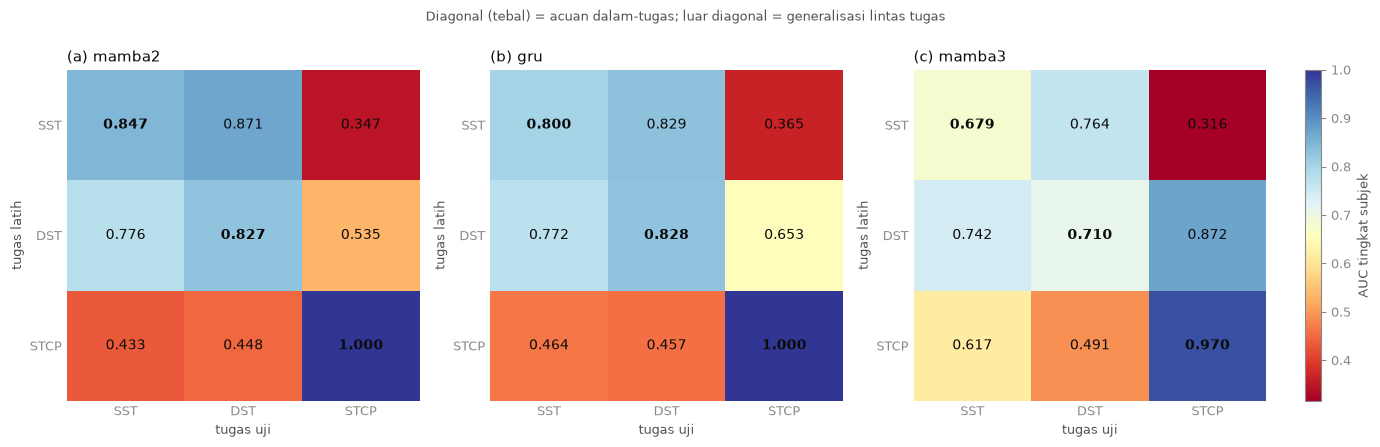

In [6]:
fig, axes = plt.subplots(1, len(ARSITEKTUR), figsize=(5.5 * len(ARSITEKTUR), 4.3))
piv_semua = [mat_df[mat_df.arsitektur == a].pivot(index="latih", columns="uji", values="auc")
             .reindex(index=urut, columns=urut) for a in ARSITEKTUR]
vmin = min(float(np.nanmin(p.values)) for p in piv_semua)
vmin = min(vmin, 0.5)

for ax, arsitektur, piv in zip(axes, ARSITEKTUR, piv_semua):
    im = ax.imshow(piv.values, cmap="RdYlBu", vmin=vmin, vmax=1.0, aspect="auto")
    ax.set_xticks(range(3)); ax.set_xticklabels(urut)
    ax.set_yticks(range(3)); ax.set_yticklabels(urut)
    ax.set_xlabel("tugas uji"); ax.set_ylabel("tugas latih")
    ax.set_title(f"({'abcdef'[ARSITEKTUR.index(arsitektur)]}) {arsitektur}", loc="left")
    for i in range(3):
        for j in range(3):
            v = piv.values[i, j]
            tebal = "bold" if i == j else "normal"
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=10,
                    fontweight=tebal, color=TINTA["utama"])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.grid(False)
    ax.tick_params(length=0)

fig.colorbar(im, ax=axes, fraction=0.032, pad=0.03, label="AUC tingkat subjek")
fig.suptitle("Diagonal (tebal) = acuan dalam-tugas; luar diagonal = generalisasi lintas tugas",
             y=1.02, fontsize=9.5, color=TINTA["sekunder"])
plt.show()

### Gambar 2 — Leave-one-task-out dan perancu pengenalan subjek

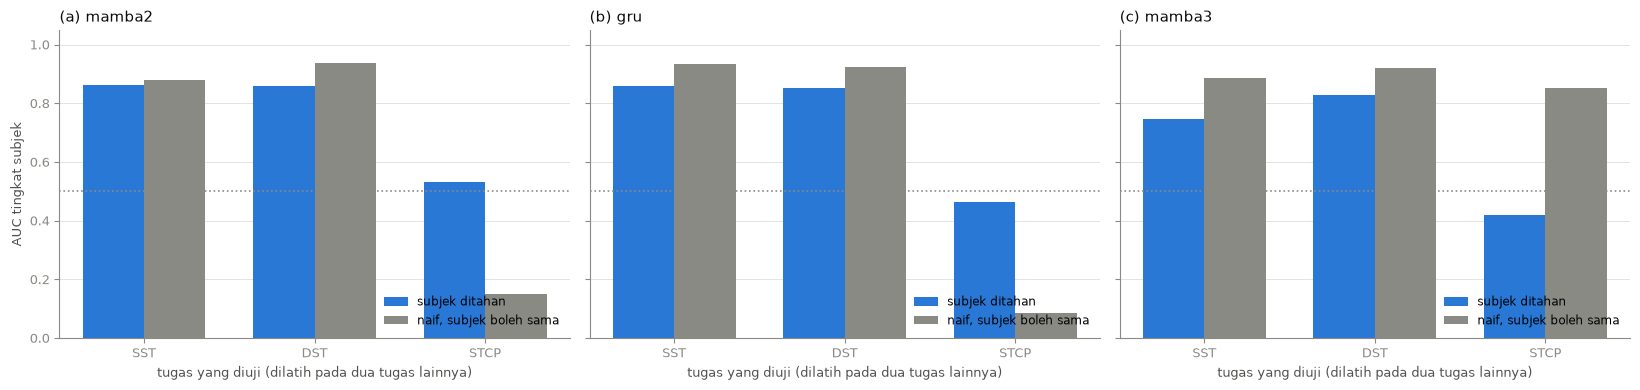

In [7]:
fig, axes = plt.subplots(1, len(ARSITEKTUR), figsize=(5.5 * len(ARSITEKTUR), 4.0), sharey=True)
pos = np.arange(len(urut)); lebar = 0.36

for ax, arsitektur in zip(axes, ARSITEKTUR):
    rapikan(ax)
    d = loto_df[loto_df.arsitektur == arsitektur].set_index("uji").reindex(urut)
    ax.bar(pos - lebar/2, d.auc_tahan_subjek, width=lebar,
           color=WARNA["biru"], label="subjek ditahan")
    ax.bar(pos + lebar/2, d.auc_naif, width=lebar,
           color=WARNA["netral"], label="naif, subjek boleh sama")
    ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
    ax.set_xticks(pos); ax.set_xticklabels(urut)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("tugas yang diuji (dilatih pada dua tugas lainnya)")
    ax.set_title(f"({'abcdef'[ARSITEKTUR.index(arsitektur)]}) {arsitektur}", loc="left")
    ax.legend(fontsize=8.5, loc="lower right")

axes[0].set_ylabel("AUC tingkat subjek")
plt.tight_layout(); plt.show()

## 5. Putusan

In [8]:
diag = mat_df[mat_df.latih == mat_df.uji].set_index(["arsitektur", "uji"]).auc
luar = mat_df[mat_df.latih != mat_df.uji]

print("=" * 78)
print("PUTUSAN SKENARIO S4")
print("=" * 78)
print(f"  Rata-rata AUC dalam-tugas (diagonal)     : {diag.mean():.4f}")
print(f"  Rata-rata AUC lintas-tugas (luar diagonal): {luar.auc.mean():.4f}")
print(f"  Selisih                                   : {diag.mean()-luar.auc.mean():+.4f}")
print()
print("  Sel lintas-tugas terlemah:")
for _, b in luar.nsmallest(3, "auc").iterrows():
    print(f"    {b.arsitektur:7s} latih {b.latih:5s} -> uji {b.uji:5s} : AUC {b.auc:.4f}")
print("  Sel lintas-tugas terkuat:")
for _, b in luar.nlargest(3, "auc").iterrows():
    print(f"    {b.arsitektur:7s} latih {b.latih:5s} -> uji {b.uji:5s} : AUC {b.auc:.4f}")
print()
print("  Klaim buta tugas (Lampiran C, G5) dinilai dari sel luar diagonal.")
print("  Mendekati diagonal berarti tanda motorik bertahan lintas tugas.")
print("  Runtuh ke 0,5 berarti yang dipelajari model bersifat khas tugas,")
print("  dan Skenario S5 kemungkinan besar gagal dengan alasan yang sama.")

mat_df.to_csv(HASIL / "s4_matriks_tugas.csv", index=False)
loto_df.to_csv(HASIL / "s4_loto.csv", index=False)
pd.DataFrame([{
    "auc_dalam_tugas": float(diag.mean()),
    "auc_lintas_tugas": float(luar.auc.mean()),
    "selisih": float(diag.mean() - luar.auc.mean()),
    "perancu_subjek_rata2": float(loto_df.perancu_subjek.mean()),
    "loto_mamba2": float(loto_df[loto_df.arsitektur == "mamba2"].auc_tahan_subjek.mean()),
    "loto_gru": float(loto_df[loto_df.arsitektur == "gru"].auc_tahan_subjek.mean()),
    "patch": P, "epochs": EPOCHS, "seed": SEED,
    "sumber": "notebooks/11_lintas_tugas.ipynb",
}]).to_csv(HASIL / "s4_putusan.csv", index=False)
print()
print(f"disimpan ke {HASIL.name}/s4_*.csv")

PUTUSAN SKENARIO S4
  Rata-rata AUC dalam-tugas (diagonal)     : 0.8511
  Rata-rata AUC lintas-tugas (luar diagonal): 0.5974
  Selisih                                   : +0.2537

  Sel lintas-tugas terlemah:
    mamba3  latih SST   -> uji STCP  : AUC 0.3161
    mamba2  latih SST   -> uji STCP  : AUC 0.3465
    gru     latih SST   -> uji STCP  : AUC 0.3647
  Sel lintas-tugas terkuat:
    mamba3  latih DST   -> uji STCP  : AUC 0.8723
    mamba2  latih SST   -> uji DST   : AUC 0.8713
    gru     latih SST   -> uji DST   : AUC 0.8292

  Klaim buta tugas (Lampiran C, G5) dinilai dari sel luar diagonal.
  Mendekati diagonal berarti tanda motorik bertahan lintas tugas.
  Runtuh ke 0,5 berarti yang dipelajari model bersifat khas tugas,
  dan Skenario S5 kemungkinan besar gagal dengan alasan yang sama.

disimpan ke results/s4_*.csv


## 6. Ringkasan

**Yang dijawab.** Lubang rancangan G5 menanyakan apakah heterogenitas tugas terlalu ekstrem bagi
model buta tugas: SST dan DST merupakan tugas menggambar, sedangkan STCP tidak melibatkan gerakan
menggambar sama sekali. Matriks pada Uji 1 menjawabnya secara langsung, bukan lewat petunjuk
tidak langsung berupa perbedaan performa per tugas pada Skenario S3.

**Peran ganda skenario ini.** S4 merupakan versi dalam-basis-data dari S5. Bila tanda motorik saja
tidak bertahan antar tugas di dalam satu basis data, dengan satu perangkat akuisisi dan satu
populasi, maka kegagalan S5 sudah dapat diperkirakan sebelum S5 dijalankan — dan penyebabnya bukan
perbedaan perangkat, melainkan sifat yang dipelajari model.

**Batasan.** Satu seed, sesuai kedalaman eksploratori Subbab 3.6.3; kesimpulan konfirmatori tetap
bersandar pada S3. Sel yang menguji STCP bersandar pada 7 subjek kontrol saja, sehingga AUC-nya
berderau besar dan tidak boleh dibaca sebagai angka presisi. Jumlah subjek dan jumlah kontrol
dicetak pada setiap sel justru agar keterbatasan itu terlihat, bukan tersembunyi di balik satu
angka tunggal.